## Setup
Import the libraries needed for the analysis.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

print("Libraries loaded successfully")

Libraries loaded successfully


## Database Connection
Connect to the PostgreSQL warehouse using SQLAlchemy.

In [ ]:
# Connection details are read from environment variables — never hardcoded.
# Set them in your shell before launching Jupyter, e.g.:
#   export DB_USER=your_local_user
#   export DB_NAME=order_fulfillment
db_user = os.environ["DB_USER"]
db_host = os.environ.get("DB_HOST", "localhost")
db_port = os.environ.get("DB_PORT", "5432")
db_name = os.environ["DB_NAME"]

engine = create_engine(f"postgresql://{db_user}@{db_host}:{db_port}/{db_name}")
print("Connection successful")

## Load Data
Load the fact table from the analytics schema into a pandas DataFrame.

In [3]:
df = pd.read_sql("SELECT * FROM analytics.fact_order_fulfillment", engine)

## Initial Exploration

Four quick checks to understand the dataset before any analysis:

- **shape** — dimensions of the DataFrame (rows × columns). Equivalent to COUNT(*) in SQL.
- **head()** — first 5 rows. Quick visual check that data loaded correctly.
- **info()** — column names, data types and null counts. Equivalent to the Phase 1 null validation queries.
- **describe()** — summary statistics for all numeric columns (min, max, mean, std, quartiles). Equivalent to the distribution analysis from Phase 1 audit.

All results consistent with warehouse validation findings: 180,519 rows, 19 columns, zero nulls.

In [4]:
df.shape

(180519, 19)

In [5]:
df.head()

,order_item_id,order_id,order_customer_id,order_item_cardprod_id,order_date_key,shipping_date_key,shipping_fulfillment_id,sales,order_item_total,order_item_quantity,benefit_per_order,order_profit_per_order,order_item_profit_ratio,order_item_discount,order_item_discount_rate,order_item_product_price,days_for_shipping_real,days_for_shipment_scheduled,late_delivery_risk
0,1,1,11599,957,20150101,20150103,11057,299.980011,239.979996,1,88.790001,88.790001,0.37,60.0,0.20,299.980011,2,4,0
1,2,2,256,1073,20150101,20150104,2554,199.990005,193.990005,1,91.180000,91.180000,0.47,6.0,0.03,199.990005,3,4,0
2,3,2,256,502,20150101,20150104,2554,250.000000,227.500000,5,68.250000,68.250000,0.30,22.5,0.09,50.000000,3,4,0
3,4,2,256,403,20150101,20150104,2554,129.990005,107.889999,1,36.470001,36.470001,0.34,22.1,0.17,129.990005,3,4,0
4,5,4,8827,897,20150101,20150106,8168,49.980000,40.980000,2,4.100000,4.100000,0.10,9.0,0.18,24.990000,5,4,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 19 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_item_id                180519 non-null  int64  
 1   order_id                     180519 non-null  int64  
 2   order_customer_id            180519 non-null  int64  
 3   order_item_cardprod_id       180519 non-null  int64  
 4   order_date_key               180519 non-null  int64  
 5   shipping_date_key            180519 non-null  int64  
 6   shipping_fulfillment_id      180519 non-null  int64  
 7   sales                        180519 non-null  float64
 8   order_item_total             180519 non-null  float64
 9   order_item_quantity          180519 non-null  int64  
 10  benefit_per_order            180519 non-null  float64
 11  order_profit_per_order       180519 non-null  float64
 12  order_item_profit_ratio      180519 non-null  float64
 13 

In [7]:
df.describe()

,order_item_id,order_id,order_customer_id,order_item_cardprod_id,order_date_key,shipping_date_key,shipping_fulfillment_id,sales,order_item_total,order_item_quantity,benefit_per_order,order_profit_per_order,order_item_profit_ratio,order_item_discount,order_item_discount_rate,order_item_product_price,days_for_shipping_real,days_for_shipment_scheduled,late_delivery_risk
count,180519.000000,180519.000000,180519.000000,180519.000000,1.805190e+05,1.805190e+05,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,90260.000000,36221.894903,6691.379495,692.509764,2.016035e+07,2.016043e+07,8256.671082,203.772096,183.107609,2.127638,21.974989,21.974989,0.120647,20.664741,0.101668,141.232550,3.497654,2.931847,0.548291
std,52111.490959,21045.379569,4162.918106,336.446807,8.255999e+03,8.278855e+03,4741.987492,132.273077,120.043670,1.453451,104.433526,104.433526,0.466796,21.800901,0.070415,139.732492,1.623722,1.374449,0.497664
min,1.000000,1.000000,1.000000,19.000000,2.015010e+07,2.015010e+07,1.000000,9.990000,7.490000,1.000000,-4274.979980,-4274.979980,-2.750000,0.000000,0.000000,9.990000,0.000000,0.000000,0.000000
25%,45130.500000,18057.000000,3258.500000,403.000000,2.015092e+07,2.015092e+07,4183.000000,119.980003,104.379997,1.000000,7.000000,7.000000,0.080000,5.400000,0.040000,50.000000,2.000000,2.000000,0.000000
50%,90260.000000,36140.000000,6457.000000,627.000000,2.016061e+07,2.016062e+07,8293.000000,199.919998,163.990005,1.000000,31.520000,31.520000,0.270000,14.000000,0.100000,59.990002,3.000000,4.000000,1.000000
75%,135389.500000,54144.000000,9779.000000,1004.000000,2.017030e+07,2.017030e+07,12189.000000,299.950012,247.399994,3.000000,64.800003,64.800003,0.360000,29.990000,0.160000,199.990005,5.000000,4.000000,1.000000
max,180519.000000,77204.000000,20757.000000,1363.000000,2.018013e+07,2.018021e+07,16606.000000,1999.989990,1939.989990,5.000000,911.799988,911.799988,0.500000,500.000000,0.250000,1999.989990,6.000000,4.000000,1.000000


## Negative Profit Analysis

During the initial exploration, `df.describe()` revealed that `order_profit_per_order` has a minimum value of -4,274.98 — meaning some orders are significantly loss-making.

## Negative Profit Analysis
Filter orders where profit is negative to understand how many orders are loss-making and what drives them.
This section investigates:
- How many orders have negative profit?
- Are high discount rates driving the losses?

In [8]:
negative_profit = df[df['order_profit_per_order'] < 0]
print(negative_profit.shape)

(33784, 19)


In [9]:
negative_profit['order_item_discount_rate'].describe()

count    33784.000000
mean         0.102222
std          0.070386
min          0.000000
25%          0.040000
50%          0.100000
75%          0.160000
max          0.250000
Name: order_item_discount_rate, dtype: float64

### Discount rate in loss-making orders

The mean discount rate for loss-making orders (10.2%) is almost identical to the overall dataset mean (10.1%). 
The minimum discount rate is 0%, meaning orders lose money even with no discount applied.

**Conclusion:** discount rate alone does not explain negative profit orders. Other factors must be driving the losses.

### Important: grain mismatch in the fact table

Not all columns in `fact_order_fulfillment` share the same grain:

- **Order item level** (one value per row): `sales`, `order_item_product_price`, 
  `order_item_discount`, `order_item_discount_rate`, `order_item_quantity`
- **Order level** (same value repeated across all items in the same order): 
  `order_profit_per_order`, `benefit_per_order`

This means if an order has 3 items, `order_profit_per_order` appears 3 times with the same value — one per row. 
Summing it directly would triple-count the profit.

This was already handled in Power BI: the `Profit_margin` measure uses SUM(profit) / SUM(sales), where the distortion cancels out at the ratio level. 
In Python, be cautious when aggregating `order_profit_per_order` at row level.

In [10]:
negative_profit[['sales','order_item_product_price','order_item_discount','order_profit_per_order']].head(10)

,sales,order_item_product_price,order_item_discount,order_profit_per_order
18,199.919998,49.980000,35.990002,-131.149994
26,21.990000,21.990000,0.660000,-15.640000
27,199.990005,199.990005,40.000000,-14.080000
40,99.959999,49.980000,14.990000,-10.620000
41,50.000000,50.000000,0.000000,-40.000000
42,50.000000,50.000000,12.500000,-61.880001
43,199.990005,199.990005,36.000000,-254.190002
44,95.970001,31.990000,6.720000,-21.240000
45,179.970001,59.990002,28.799999,-72.559998
46,399.980011,399.980011,68.000000,-121.839996


## Findings
Negative profit orders are not simpli explained by discounts. The losses suggest either products sold below cost, or order-level costs (shipping, handlging, returns) not captured in our item-level columns.
Note that the grain mismatched before, larger losses may b coming from other items in the same order, not just this line item.

## Conclusion: Negative Profit Orders

33,784 orders (18.7% of total) show negative profit. Investigation shows 
this cannot be explained by discount rates alone:

- The mean discount rate for loss-making orders (10.2%) is virtually 
  identical to the overall dataset mean (10.1%)
- Some orders show negative profit with zero discount applied (e.g. row 41: 
  sales = $50, discount = $0, profit = -$40)
- In some cases the loss exceeds the discount amount by a large margin

**Likely explanations:**
- Products sold below cost (pricing strategy or error)
- Order-level costs not captured at item level (shipping, handling, returns)

**Important caveat:** due to the grain mismatch in the fact table, 
`order_profit_per_order` reflects the total order result — large losses 
on one row may originate from other items in the same order, not the 
specific line item being observed.

**This finding was not visible in the Power BI dashboard**, where profit 
margin was reported as an aggregate (10.78%). Python EDA revealed the 
distribution underneath that average.

## Delivery Time Distribution Analysis

The Power BI dashboard showed an average delivery time of 3.50 days — but an average alone doesn't tell the full story. This analysis uses a histogram to visualize how delivery times are actually distributed across all 180,519 order items, revealing patterns that aggregate metrics cannot capture.

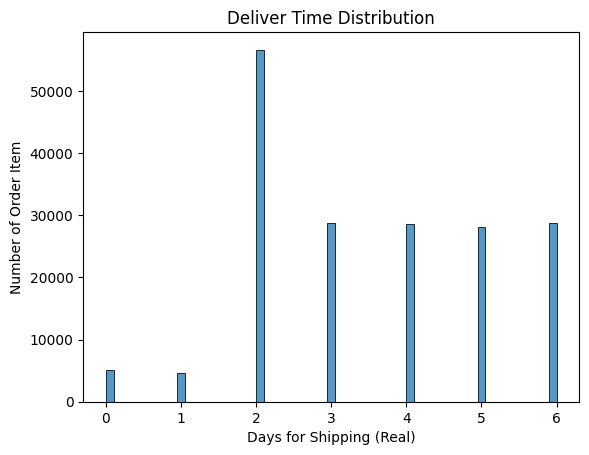

In [11]:
sns.histplot(data=df, x='days_for_shipping_real')
plt.title('Deliver Time Distribution')
plt.xlabel('Days for Shipping (Real)')
plt.ylabel('Number of Order Item')
plt.show()

## Finding: Delivery Time Distribution

The histogram reveals a bimodal distribution that the average of 3.50 days was hiding:

- A dominant spike at **2 days** (~56,000 order items) — driven by First Class shipments
- A flat plateau from **3 to 6 days** (~29,000 order items each) — Standard, Second Class and Same Day combined
- Very few orders deliver in 0 or 1 days

**Business implication:** the four shipping modes do not create four distinct delivery experiences. In practice the operation produces only two real profiles: 2-day delivery and 3-6 day delivery. The current shipping mode structure may be overcomplicated — a simpler two-tier model (express vs standard) would better reflect operational reality.

**This finding was not visible in the Power BI dashboard**, where delivery time was shown only as an average card (3.50 days). Python EDA revealed the distribution underneath that number.

## Delivery Time by Shipping Mode

Loading the shipping dimension to join with the fact table and analyze how delivery times distribute across shipping modes.

Loading and joining dim_shipping_fulfillment table.

In [12]:
df_shipping = pd.read_sql("SELECT * FROM analytics.dim_shipping_fulfillment", engine)

In [13]:
df_shipping_merged = df.merge(df_shipping, on='shipping_fulfillment_id')
print(df_shipping_merged.shape)

(180519, 26)


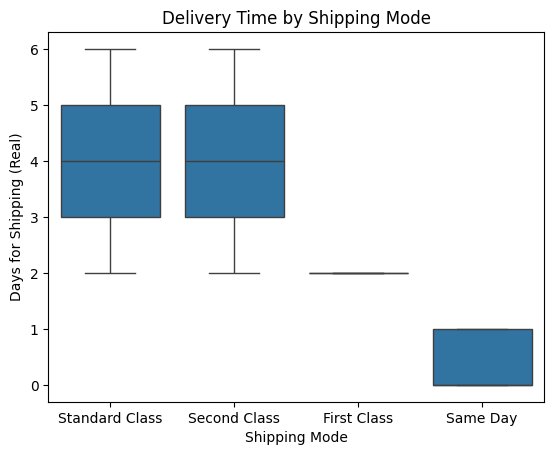

In [14]:
sns.boxplot(data=df_shipping_merged, x='shipping_mode', y='days_for_shipping_real')
plt.title('Delivery Time by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Days for Shipping (Real)')
plt.show()

## Finding: Delivery Time by Shipping Mode

The boxplot reveals the operational reality behind the four shipping modes:

- **First Class** — a flat line at exactly 2 days with zero variation. 
Every order promises 2-day delivery with no flexibility. 
This explains the 95.32% late delivery rate seen in Power BI: any deviation from the 2-day window is flagged as late, making the service level promise structurally hard to meet.

- **Same Day** — small box between 0 and 1 day. Consistently fast with limited variation.

- **Standard Class and Second Class** — almost identical boxes, both spreading from 2 to 6 days with a median around 4 days. These two modes are operationally indistinguishable — confirming the Phase 1 audit finding and supporting the hypothesis that the four-tier shipping structure may be reducible to two real tiers: express (2 days) and standard (3-6 days).

This finding connects the delivery time histogram and the late delivery rate analysis into a single coherent explanation: the operation has two real delivery profiles, but four pricing tiers — creating service expectation mismatches that drive the high late delivery rate.

## Discount Rate vs Profit Margin: Correlation Analysis

The Power BI dashboard showed a visual pattern — profit margin decreases as discount rate increases. This section quantifies that relationship with a correlation coefficient to confirm its strength and statistical validity.

Using `order_item_profit_ratio` instead of `order_profit_per_order`, since both `order_item_discount_rate` and `order_item_profit_ratio` share the same grain (order item level) — avoiding the grain mismatch issue documented earlier.

In [15]:
df['order_item_discount_rate'].corr(df['order_item_profit_ratio'])

np.float64(-0.0026908104237598662)

## Finding: Correlation is Near-Zero at the Row Level

The correlation coefficient between `order_item_discount_rate` and `order_item_profit_ratio` is **-0.0027** — essentially no linear relationship at the individual order item level.

This appears to contradict the Power BI finding, where average profit margin clearly decreased as discount band increased. The two results are not actually in conflict — they operate at different levels of aggregation:

- **Power BI** measured average profit margin **per discount band** (grouped, aggregated data). Grouping cancels out noise from other variables and reveals the underlying trend.
- **This analysis** measures the relationship across **180,519 individual rows**, where many other factors (product type, base price, quantity, shipping cost structure) influence profit ratio simultaneously, burying any single-variable effect in noise.

**Conclusion:** discount rate does have a real, measurable effect on profit margin in aggregate — but at the individual order level, its effect is too weak to detect on its own. This is a common pattern in real-world data: trends visible in grouped averages often disappear at the row level because individual variation is dominated by multiple interacting factors. A more rigorous analysis (e.g. multiple regression controlling for other variables) would be needed to isolate discount rate's true individual effect.

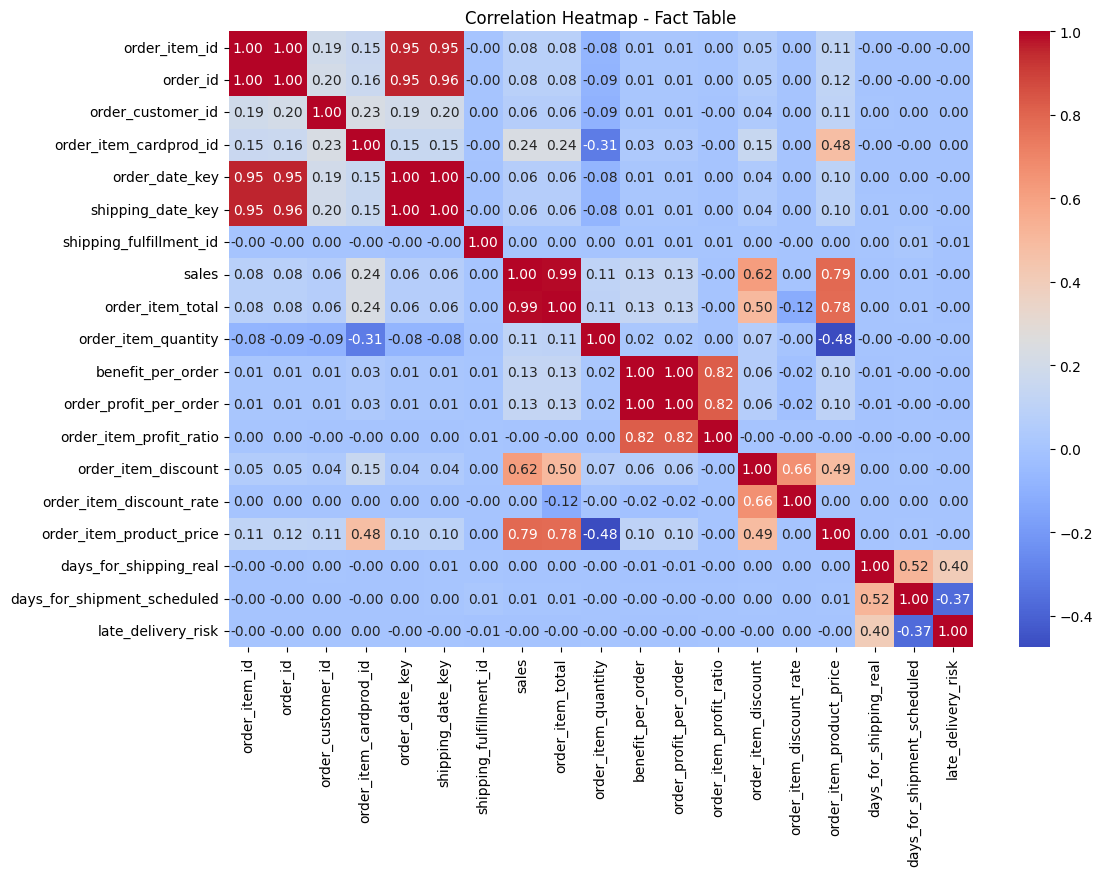

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Fact Table')
plt.show()

## Finding: Correlation Heatmap — Fact Table

Excluding IDs and keys (structural, not analytical), the heatmap reveals several meaningful relationships:

- **Discount rate vs profit ratio (0.00)** — confirms, via a second method,   the near-zero relationship found earlier. No linear effect at the row level.

- **Scheduled shipping days vs late delivery risk (-0.37)** — shorter promised   delivery windows correlate with higher risk of being flagged late. This   supports the boxplot finding: First Class promises only 2 days with zero   flexibility, making it structurally prone to being marked late.

- **Real shipping days vs late delivery risk (0.40)** — intuitive positive   relationship: the longer an order actually takes, the more likely it is flagged late.

- **Order item quantity vs product price (-0.48)** — customers tend to buy fewer units of more expensive items.

- **Discount amount vs sales (0.62)** — larger orders receive larger discounts in dollar terms, expected since discount amount is partly a function of order value (distinct from discount rate, which showed no such pattern).

**Overall:** the heatmap reinforces and connects findings from earlier in the notebook (delivery time analysis, discount-profit correlation) while surfacing two new relationships (quantity vs price, discount amount vs sales) not previously explored.

## Regression Analysis: What Predicts Profit Ratio?

Multiple linear regression (OLS) testing whether discount rate, product price 
and quantity can explain variation in profit ratio at the order item level.
Extends the correlation analysis by controlling for multiple variables simultaneously.

In [22]:
import statsmodels.api as sm
X = df[['order_item_discount_rate','order_item_product_price','order_item_quantity']]
y = df['order_item_profit_ratio']

In [23]:
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     order_item_profit_ratio   R-squared:                       0.000
Model:                                 OLS   Adj. R-squared:                 -0.000
Method:                      Least Squares   F-statistic:                    0.6886
Date:                     Wed, 01 Jul 2026   Prob (F-statistic):              0.559
Time:                             09:37:48   Log-Likelihood:            -1.1861e+05
No. Observations:                   180519   AIC:                         2.372e+05
Df Residuals:                       180515   BIC:                         2.373e+05
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

## Finding: No Variable Predicts Profit Ratio at Row Level

- **R-squared = 0.000** — the three variables explain 0% of profit ratio variation
- **F-statistic p-value = 0.559** — the model as a whole is not statistically significant
- **All three variables individually non-significant** (p-values: discount rate 0.25, product price 0.47, quantity 0.94)

Consistent with both the individual correlation (-0.003) and the heatmap findings. 
Profit ratio variation is driven by factors not captured in these columns — likely 
order-level cost structures or operational data absent from the dataset.

This closes the discount-profit investigation: the relationship exists in aggregate 
(visible in Power BI) but cannot be detected at the individual row level regardless 
of the method used.